## Importing pyplot


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11


## Loading Data CSV File

In [2]:
try:
    from google.colab import files
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
except ImportError:
    filename = "dataset.csv"

df = pd.read_csv(filename, skiprows=[1])

df['Value'] = pd.to_numeric(df['Value'], errors='coerce')
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df = df.dropna(subset=['Value', 'Year'])

df.head()


Saving dataset.csv to dataset.csv


,refArea,EndDate,StartDate,structure,Value,Observation URI,references,Month,publisher,Item Code,Year,dataset,Item
0,http://dbpedia.org/resource/Lebanon,2000-04-30,2000-04-01,NaN,36.702048,http://linked.aub.edu.lb/CODEC/Lebanon/observa...,https://data.humdata.org/dataset/faostat-food-...,April,Food and Agriculture Organization,23013,2000,http://linked.aub.edu.lb/CODEC/Lebanon/Dataset...,"Consumer Prices, Food Indices (2015 = 100)"
1,http://dbpedia.org/resource/Lebanon,2001-04-30,2001-04-01,NaN,40.818778,http://linked.aub.edu.lb/CODEC/Lebanon/observa...,https://data.humdata.org/dataset/faostat-food-...,April,Food and Agriculture Organization,23013,2001,http://linked.aub.edu.lb/CODEC/Lebanon/Dataset...,"Consumer Prices, Food Indices (2015 = 100)"
2,http://dbpedia.org/resource/Lebanon,2002-04-30,2002-04-01,NaN,44.935509,http://linked.aub.edu.lb/CODEC/Lebanon/observa...,https://data.humdata.org/dataset/faostat-food-...,April,Food and Agriculture Organization,23013,2002,http://linked.aub.edu.lb/CODEC/Lebanon/Dataset...,"Consumer Prices, Food Indices (2015 = 100)"
3,http://dbpedia.org/resource/Lebanon,2003-04-30,2003-04-01,NaN,49.052239,http://linked.aub.edu.lb/CODEC/Lebanon/observa...,https://data.humdata.org/dataset/faostat-food-...,April,Food and Agriculture Organization,23013,2003,http://linked.aub.edu.lb/CODEC/Lebanon/Dataset...,"Consumer Prices, Food Indices (2015 = 100)"
4,http://dbpedia.org/resource/Lebanon,2004-04-30,2004-04-01,NaN,53.256055,http://linked.aub.edu.lb/CODEC/Lebanon/observa...,https://data.humdata.org/dataset/faostat-food-...,April,Food and Agriculture Organization,23013,2004,http://linked.aub.edu.lb/CODEC/Lebanon/Dataset...,"Consumer Prices, Food Indices (2015 = 100)"


## Viewing the Data

In [3]:
print("Shape:", df.shape)
print("\nIndicator types (Item column):")
print(df['Item'].unique())
print("\nYear range:", int(df['Year'].min()), "-", int(df['Year'].max()))
df.info()


Shape: (843, 13)

Indicator types (Item column):
['Consumer Prices, Food Indices (2015 = 100)'
 'Consumer Prices, General Indices (2015 = 100)' 'Food price inflation']

Year range: 2000 - 2023
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 843 entries, 0 to 842
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   refArea          843 non-null    object 
 1   EndDate          843 non-null    object 
 2   StartDate        843 non-null    object 
 3   structure        0 non-null      float64
 4   Value            843 non-null    float64
 5   Observation URI  843 non-null    object 
 6   references       843 non-null    object 
 7   Month            843 non-null    object 
 8   publisher        843 non-null    object 
 9   Item Code        843 non-null    int64  
 10  Year             843 non-null    int64  
 11  dataset          843 non-null    object 
 12  Item             843 non-null    object 
dtypes: floa

## Data Aggregating and Cleaning

In [4]:
food_index = df[df['Item'] == 'Consumer Prices, Food Indices (2015 = 100)']
general_index = df[df['Item'] == 'Consumer Prices, General Indices (2015 = 100)']
inflation = df[df['Item'] == 'Food price inflation']

food_annual = food_index.groupby('Year')['Value'].mean()
general_annual = general_index.groupby('Year')['Value'].mean()
inflation_annual = inflation.groupby('Year')['Value'].mean()


---
# Visualization 1: Line Chart

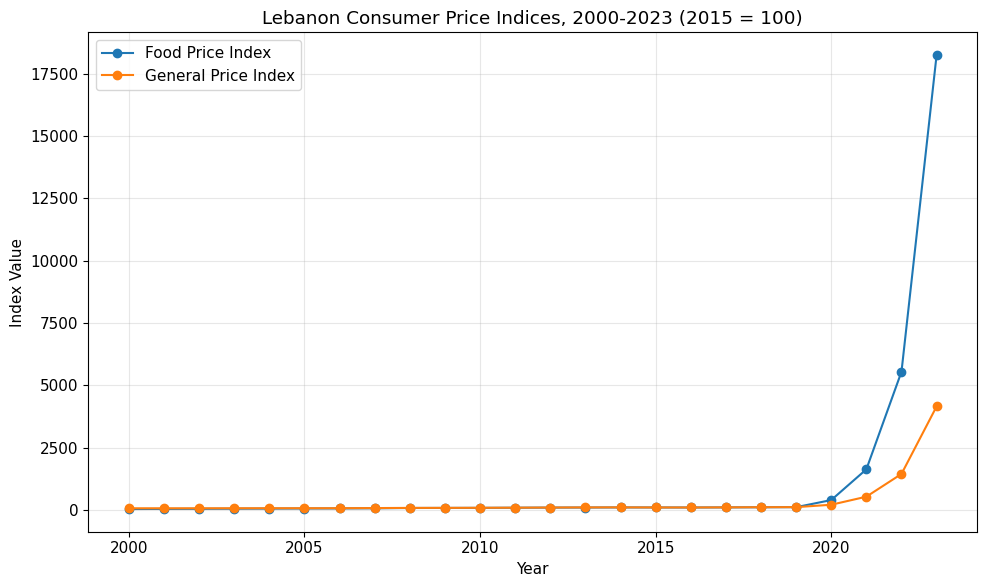

In [5]:
plt.figure()
plt.plot(food_annual.index, food_annual.values, marker='o', label='Food Price Index')
plt.plot(general_annual.index, general_annual.values, marker='o', label='General Price Index')
plt.title('Lebanon Consumer Price Indices, 2000-2023 (2015 = 100)')
plt.xlabel('Year')
plt.ylabel('Index Value')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---
# Visualization 2: Bar Chart



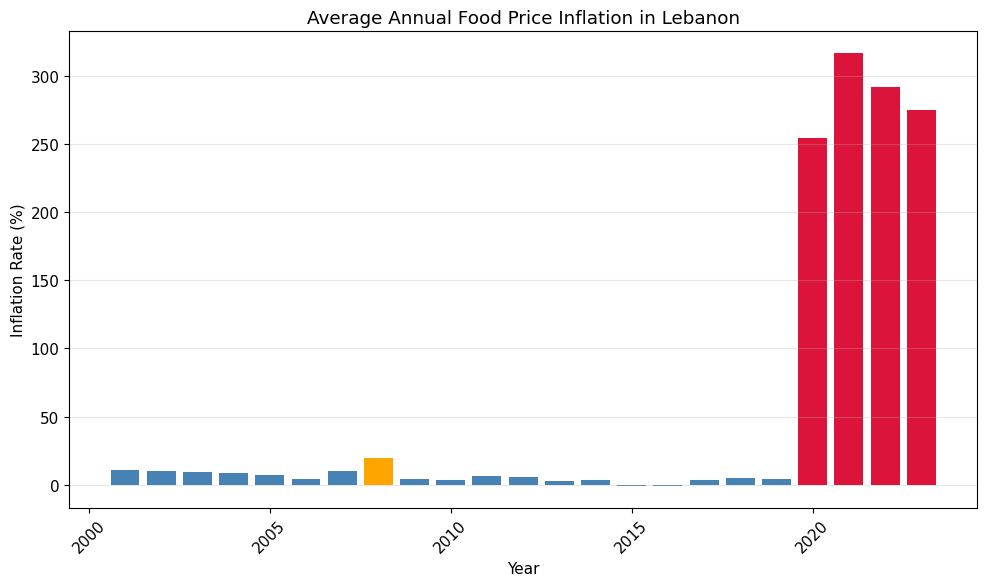

In [6]:
colors = ['crimson' if v > 50 else ('orange' if v > 15 else 'steelblue')
          for v in inflation_annual.values]

plt.figure()
plt.bar(inflation_annual.index.astype(int), inflation_annual.values, color=colors)
plt.title('Average Annual Food Price Inflation in Lebanon')
plt.xlabel('Year')
plt.ylabel('Inflation Rate (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


---
#Visualization 3: Pie Chart

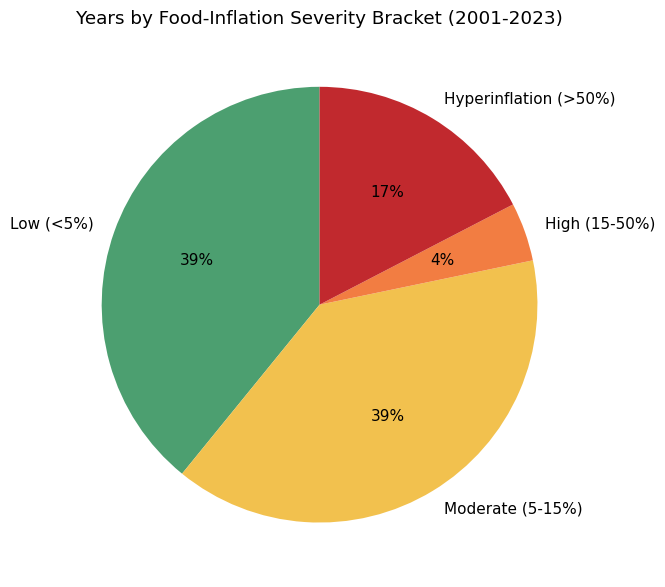

In [7]:
def bracket(v):
    if v < 5:
        return 'Low (<5%)'
    elif v < 15:
        return 'Moderate (5-15%)'
    elif v < 50:
        return 'High (15-50%)'
    else:
        return 'Hyperinflation (>50%)'

order = ['Low (<5%)', 'Moderate (5-15%)', 'High (15-50%)', 'Hyperinflation (>50%)']
brackets = inflation_annual.apply(bracket).value_counts().reindex(order).fillna(0)

plt.figure()
plt.pie(
    brackets.values,
    labels=brackets.index,
    autopct='%1.0f%%',
    startangle=90,
    colors=['#4C9F70', '#F2C14E', '#F27D42', '#C1292E']
)
plt.title('Years by Food-Inflation Severity Bracket (2001-2023)')
plt.tight_layout()
plt.show()


---
# Visualization 4: Histogram

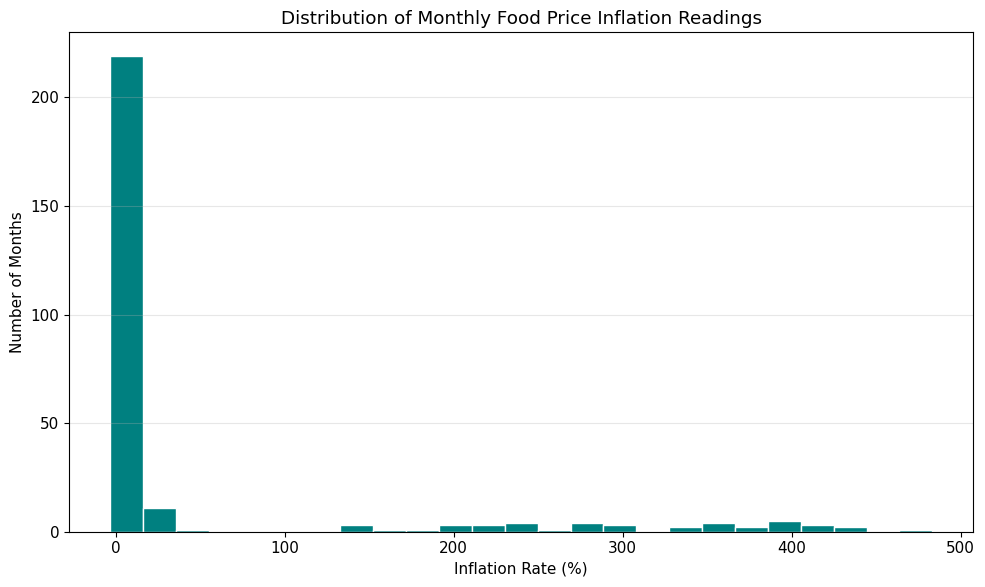

In [8]:
plt.figure()
plt.hist(inflation['Value'], bins=25, color='teal', edgecolor='white')
plt.title('Distribution of Monthly Food Price Inflation Readings')
plt.xlabel('Inflation Rate (%)')
plt.ylabel('Number of Months')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


---
# Visualization 5: Scatter Plot

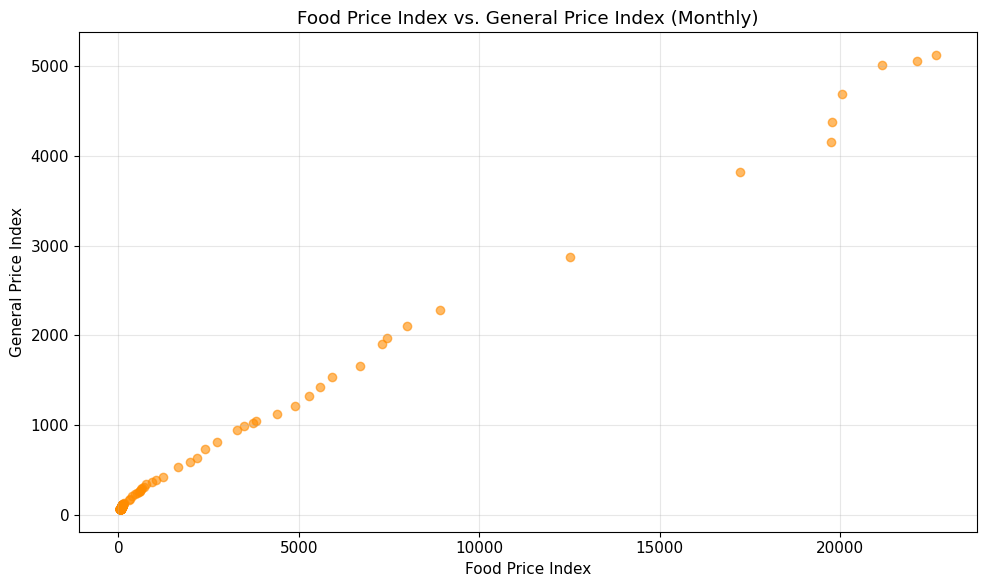

In [9]:
merged = pd.merge(
    food_index[['Year', 'Month', 'Value']].rename(columns={'Value': 'Food_Index'}),
    general_index[['Year', 'Month', 'Value']].rename(columns={'Value': 'General_Index'}),
    on=['Year', 'Month']
)

plt.figure()
plt.scatter(merged['Food_Index'], merged['General_Index'], alpha=0.6, color='darkorange')
plt.title('Food Price Index vs. General Price Index (Monthly)')
plt.xlabel('Food Price Index')
plt.ylabel('General Price Index')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
